In [10]:
df = pd.read_csv("C:/Users/Bhuvaneshwari L/Downloads/quick_comm2.csv")
df1  = pd.DataFrame(df)

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('Display.max_columns',None)
sns.set_style('whitegrid')

df = pd.read_csv("C:/Users/Bhuvaneshwari L/Downloads/quick_comm2.csv")
print(df.shape)
df.info()

(947752, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  float64
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  float64
 4   Age_Bucket               947752 non-null  object 
 5   Order_Value              947752 non-null  float64
 6   Delivery_Time_Min        947752 non-null  int64  
 7   Distance_time_bucket     947752 non-null  object 
 8   Distance_Km              947752 non-null  float64
 9   Distance_Bucket          947752 non-null  object 
 10  Items_Count              947752 non-null  int64  
 11  Product_Category         947752 non-null  object 
 12  Payment_Method           947752 non-null  object 
 13  Customer_Rating          947752 non-null  floa

In [14]:
df1 = df1.loc[:, ~df1.columns.str.contains('^Unnamed')]

In [16]:
df1 = df1.astype({
    'Order_ID': 'int64',
    'Customer_Age': 'int64'
})

In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947752 entries, 0 to 947751
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Order_ID                 947752 non-null  int64  
 1   Company                  947752 non-null  object 
 2   City                     947752 non-null  object 
 3   Customer_Age             947752 non-null  int64  
 4   Age_Bucket               947752 non-null  object 
 5   Order_Value              947752 non-null  float64
 6   Delivery_Time_Min        947752 non-null  int64  
 7   Distance_time_bucket     947752 non-null  object 
 8   Distance_Km              947752 non-null  float64
 9   Distance_Bucket          947752 non-null  object 
 10  Items_Count              947752 non-null  int64  
 11  Product_Category         947752 non-null  object 
 12  Payment_Method           947752 non-null  object 
 13  Customer_Rating          947752 non-null  float64
 14  Disc

In [18]:
df1.head(3)

,Order_ID,Company,City,Customer_Age,Age_Bucket,Order_Value,Delivery_Time_Min,Distance_time_bucket,Distance_Km,Distance_Bucket,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Cost,Discount_Amt,Profit,In_Loss,Loss_Driver
0,1000001,Swiggy Instamart,Noida,46,45-54,702.0,19,16-30 Mins,12.0,8+ KM,12,Dairy,Wallet,2.0,1,3.0,125.0,70.2,506.8,0,Long Distance
1,1000002,Flipkart Minutes,Amritsar,56,55+,1007.0,20,16-30 Mins,12.7,8+ KM,10,Snacks,Cash on Delivery,2.0,0,3.0,130.6,0.0,876.4,0,Long Distance
2,1000003,Flipkart Minutes,Mumbai,18,Under 25,1212.0,17,16-30 Mins,4.8,2-5 KM,19,Personal Care,Cash on Delivery,3.0,0,4.0,67.4,0.0,1144.6,0,Normal


In [19]:
df1.tail(3)

,Order_ID,Company,City,Customer_Age,Age_Bucket,Order_Value,Delivery_Time_Min,Distance_time_bucket,Distance_Km,Distance_Bucket,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Cost,Discount_Amt,Profit,In_Loss,Loss_Driver
947749,1999998,Jio Mart,Noida,29,25-34,637.0,18,16-30 Mins,2.6,2-5 KM,6,Groceries,Cash on Delivery,3.0,0,5.0,49.8,0.0,587.2,0,Normal
947750,1999999,Dunzo,Pune,42,35-44,1103.0,13,0-15 Mins,7.8,5-8 KM,12,Snacks,Wallet,4.0,1,4.0,91.4,11.0,1000.6,0,Normal
947751,2000000,Amazon Now,Chennai,19,Under 25,759.0,18,16-30 Mins,9.4,8+ KM,13,Snacks,Credit Card,4.0,0,5.0,104.2,0.0,654.8,0,Long Distance


In [20]:
df1.shape

(947752, 21)

In [21]:
print("Number of Rows",df1.shape[0])
print("Number of colms",df1.shape[1])

Number of Rows 947752
Number of colms 21


In [37]:
df1.isnull().sum()

Order_ID                   0
Company                    0
City                       0
Customer_Age               0
Age_Bucket                 0
Order_Value                0
Delivery_Time_Min          0
Distance_time_bucket       0
Distance_Km                0
Distance_Bucket            0
Items_Count                0
Product_Category           0
Payment_Method             0
Customer_Rating            0
Discount_Applied           0
Delivery_Partner_Rating    0
Delivery_Cost              0
Discount_Amt               0
Profit                     0
In_Loss                    0
Loss_Driver                0
dtype: int64

In [25]:
#Duplicates
print("Duplicate Order_IDs:", df['Order_ID'].duplicated().sum())
print("Full row duplicates:",df.duplicated().sum())

Duplicate Order_IDs: 0
Full row duplicates: 0


In [30]:
#Invalid/impossible values
checks={
    'Order_Value <= 0': (df['Order_Value']<=0).sum(),
    'Distance_Km <= 0':  (df['Distance_Km']<=0).sum(),
    'Delivery_Time_Min <=0': (df['Delivery_Time_Min']<=0).sum(),
    'Items_Count <= 0':      (df['Items_Count']<=0).sum(),
    'Delivery_Cost < 0':     (df['Delivery_Cost']<0).sum(),
    'Discount_Amt < 0':      (df['Discount_Amt']<0).sum(),
} 
print(checks)

{'Order_Value <= 0': np.int64(0), 'Distance_Km <= 0': np.int64(0), 'Delivery_Time_Min <=0': np.int64(0), 'Items_Count <= 0': np.int64(0), 'Delivery_Cost < 0': np.int64(0), 'Discount_Amt < 0': np.int64(0)}


In [31]:
#Category Consistency 
for c in ['Company','City','Product_Category','Payment_Method','Distance_Bucket','Age_Bucket','Distance_time_bucket','Loss_Driver']:
    print(c,'->',sorted(df[c].unique().tolist()))

Company -> ['Amazon Now', 'Big Basket', 'Blinkit', 'Dunzo', 'Flipkart Minutes', 'Jio Mart', 'Swiggy Instamart', 'Zepto']
City -> ['Amritsar', 'Bengluru', 'Chennai', 'Delhi', 'Gurgaon', 'Haridwar', 'Hyderabad', 'Jaipur', 'Kolkata', 'Mumbai', 'Noida', 'Pune']
Product_Category -> ['Beverages', 'Dairy', 'Fruits & Vegetables', 'Groceries', 'Household', 'Personal Care', 'Snacks']
Payment_Method -> ['Cash on Delivery', 'Credit Card', 'Debit Card', 'UPI', 'Wallet']
Distance_Bucket -> ['0-2 KM', '2-5 KM', '5-8 KM', '8+ KM']
Age_Bucket -> ['25-34', '35-44', '45-54', '55+', 'Under 25']
Distance_time_bucket -> ['0-15 Mins', '16-30 Mins', '31-45 Mins']
Loss_Driver -> ['Discounted', 'Long Distance', 'Low Value Order', 'Normal']


In [32]:
df['City']=df['City'].str.strip().str.title()

In [34]:
#RAting and flag ranges
print('Customer_Rating:', df['Customer_Rating'].min(), '-', df['Customer_Rating'].max())
print('Delivery_Partner_Rating:', df['Delivery_Partner_Rating'].min(), '-', df['Delivery_Partner_Rating'].max())
print('Discount_Applied uniques:', df['Discount_Applied'].unique())
print('In_Loss uniques:', df['In_Loss'].unique())


Customer_Rating: 1.0 - 5.0
Delivery_Partner_Rating: 2.0 - 5.0
Discount_Applied uniques: [1 0]
In_Loss uniques: [0 1]


In [36]:
#logical Consistency check(Profit)
df['calc_check'] = df['Order_Value']-df['Delivery_Cost']-df['Discount_Amt']
print((df['calc_check'] - df['Profit']).describe())

count    9.477520e+05
mean    -3.621517e-03
std      1.868252e-02
min     -1.000000e-01
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.547474e-13
dtype: float64


In [26]:
#statistics
df1.describe()

,Order_ID,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Cost,Discount_Amt,Profit,In_Loss
count,9.477520e+05,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000,947752.000000
mean,1.500028e+06,38.471165,570.912008,16.506620,7.750048,10.313292,3.042655,0.400786,3.800295,91.000385,2.856269,477.058975,0.097696
std,2.887273e+05,12.118982,374.175332,6.340851,4.187153,5.630770,1.202499,0.490058,0.718762,33.497224,4.454467,372.548919,0.296904
min,1.000001e+06,18.000000,50.000000,5.000000,0.500000,1.000000,1.000000,0.000000,2.000000,33.000000,0.000000,-99.500000,0.000000
25%,1.249939e+06,28.000000,288.000000,12.000000,4.100000,5.000000,2.000000,0.000000,3.000000,61.800000,0.000000,195.000000,0.000000
50%,1.500026e+06,38.000000,532.000000,16.000000,7.800000,10.000000,3.000000,0.000000,4.000000,91.400000,0.000000,439.000000,0.000000
75%,1.750145e+06,49.000000,797.000000,20.000000,11.400000,15.000000,4.000000,1.000000,4.000000,120.200000,5.500000,703.000000,0.000000
max,2.000000e+06,59.000000,2492.000000,40.000000,15.000000,19.000000,5.000000,1.000000,5.000000,149.000000,70.200000,2421.300000,1.000000


In [37]:
#outliner check 
q1, q3 = df['Delivery_Time_Min'].quantile([.25, .75])
iqr = q3 - q1
upper = q3 + 1.5*iqr
print(f"IQR bounds: {q1}-{q3}, upper fence: {upper}")
print("Rows above upper fence:", (df['Delivery_Time_Min'] > upper).sum())

IQR bounds: 12.0-20.0, upper fence: 32.0
Rows above upper fence: 11299


In [39]:
#Unique value
df1

,Order_ID,Company,City,Customer_Age,Age_Bucket,Order_Value,Delivery_Time_Min,Distance_time_bucket,Distance_Km,Distance_Bucket,...,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Cost,Discount_Amt,Profit,In_Loss,Loss_Driver
0,1000001,Swiggy Instamart,Noida,46,45-54,702.0,19,16-30 Mins,12.0,8+ KM,...,Dairy,Wallet,2.0,1,3.0,125.0,70.2,506.8,0,Long Distance
1,1000002,Flipkart Minutes,Amritsar,56,55+,1007.0,20,16-30 Mins,12.7,8+ KM,...,Snacks,Cash on Delivery,2.0,0,3.0,130.6,0.0,876.4,0,Long Distance
2,1000003,Flipkart Minutes,Mumbai,18,Under 25,1212.0,17,16-30 Mins,4.8,2-5 KM,...,Personal Care,Cash on Delivery,3.0,0,4.0,67.4,0.0,1144.6,0,Normal
3,1000004,Swiggy Instamart,Delhi,23,Under 25,1179.0,6,0-15 Mins,6.4,5-8 KM,...,Dairy,Credit Card,5.0,1,5.0,80.2,11.8,1087.0,0,Normal
4,1000005,Dunzo,Mumbai,44,35-44,586.0,12,0-15 Mins,2.4,2-5 KM,...,Household,Wallet,4.0,0,5.0,48.2,0.0,537.8,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947747,1999996,Big Basket,Mumbai,48,45-54,72.0,18,16-30 Mins,3.0,2-5 KM,...,Fruits & Vegetables,Wallet,4.0,0,3.0,53.0,0.0,19.0,0,Low Value Order
947748,1999997,Swiggy Instamart,Mumbai,33,25-34,1510.0,18,16-30 Mins,10.5,8+ KM,...,Beverages,Debit Card,4.0,1,4.0,113.0,15.1,1381.9,0,Long Distance
947749,1999998,Jio Mart,Noida,29,25-34,637.0,18,16-30 Mins,2.6,2-5 KM,...,Groceries,Cash on Delivery,3.0,0,5.0,49.8,0.0,587.2,0,Normal
947750,1999999,Dunzo,Pune,42,35-44,1103.0,13,0-15 Mins,7.8,5-8 KM,...,Snacks,Wallet,4.0,1,4.0,91.4,11.0,1000.6,0,Normal


In [39]:
#Feature Engineering
df['Profit_Margin_%'] = (df['Profit'] / df['Order_Value']) * 100
df['Cost_to_Serve_%']  = ((df['Delivery_Cost'] + df['Discount_Amt']) / df['Order_Value']) * 100
df['Rev_per_KM']       = df['Order_Value'] / df['Distance_Km'].replace(0, np.nan)
df['Is_Weekend']       = None


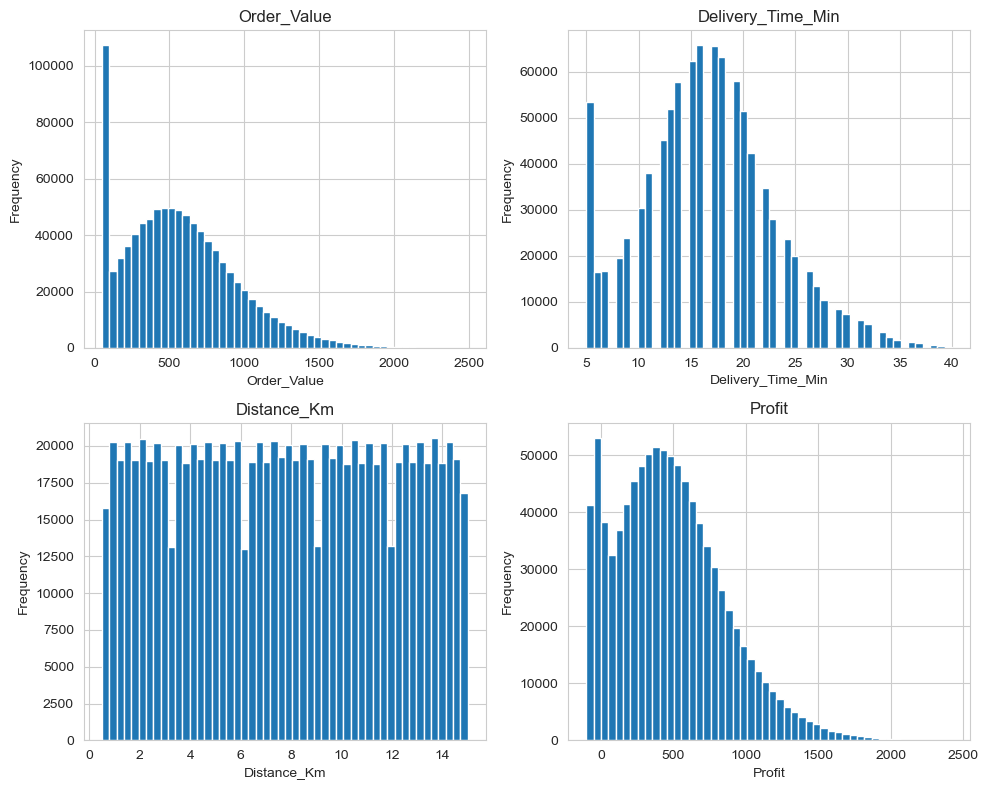

In [49]:
#EDA
#Distribution shape 
df[['Order_Value', 'Delivery_Time_Min', 'Distance_Km', 'Profit']].describe().round(2)

axes = df[['Order_Value','Delivery_Time_Min','Distance_Km','Profit']].hist(figsize=(10,8), bins=50)

for ax in axes.flatten():
    ax.set_ylabel("Frequency")
    ax.set_xlabel(ax.get_title())

plt.tight_layout()
plt.show()


In [50]:
#EDA- category balance 
for col in ['Company','City','Product_Category','Payment_Method','Age_Bucket']:
    print(df[col].value_counts(normalize=True).round(3)*100, '/n')

Company
Flipkart Minutes    12.6
Blinkit             12.5
Zepto               12.5
Swiggy Instamart    12.5
Dunzo               12.5
Jio Mart            12.5
Amazon Now          12.5
Big Basket          12.5
Name: proportion, dtype: float64 /n
City
Hyderabad    8.4
Delhi        8.4
Kolkata      8.4
Amritsar     8.3
Mumbai       8.3
Gurgaon      8.3
Bengluru     8.3
Haridwar     8.3
Jaipur       8.3
Noida        8.3
Chennai      8.3
Pune         8.3
Name: proportion, dtype: float64 /n
Product_Category
Dairy                  14.4
Groceries              14.3
Snacks                 14.3
Household              14.3
Beverages              14.3
Personal Care          14.3
Fruits & Vegetables    14.2
Name: proportion, dtype: float64 /n
Payment_Method
Cash on Delivery    20.1
Credit Card         20.0
Debit Card          20.0
UPI                 20.0
Wallet              19.9
Name: proportion, dtype: float64 /n
Age_Bucket
25-34       23.8
35-44       23.8
45-54       23.7
Under 25    16.7
55+    

Company: Orders are evenly distributed across all companies, with Flipkart Minutes slightly leading at 12.6%.
City: Order demand is balanced across all cities, with Hyderabad, Delhi, and Kolkata contributing the highest share (8.4% each).
Product Category: Customer demand is well distributed across all product categories, with each contributing around 14% of total orders.
Payment Method: Customers use all payment methods almost equally, with Cash on Delivery slightly leading at 20.1%.
Age Bucket: The majority of customers belong to the 25–44 age group, making them the primary customer segment.


In [56]:
#EDA- In_loss rate 
print("Overall loss rate:", (df['In_Loss'].mean()*100).round(2), "%")
print(df['Loss_Driver'].value_counts(normalize=True).round(3)*100)



Overall loss rate: 9.77 %
Loss_Driver
Long Distance      35.4
Normal             34.5
Low Value Order    26.1
Discounted          4.0
Name: proportion, dtype: float64


Only 9.77% of orders are unprofitable, with over one-third of these losses caused by Long Distance deliveries. Optimizing delivery radius and improving unit economics for low-value orders could significantly reduce overall losses.

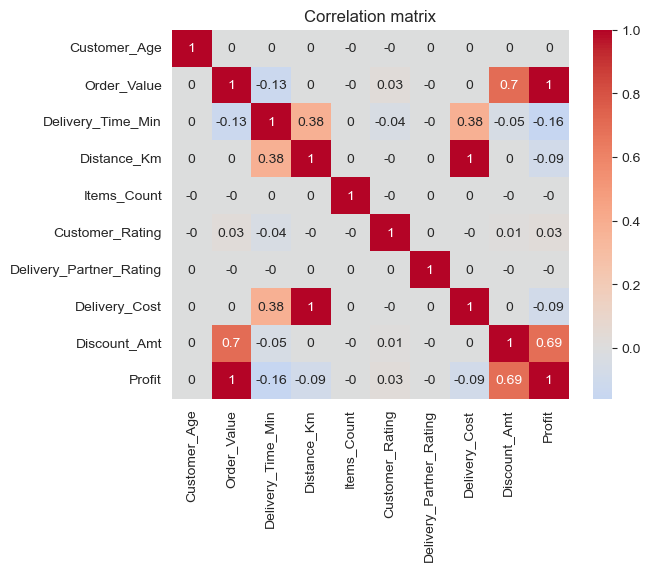

In [59]:
#Eda - Correlation matrix
numeric_cols = ['Customer_Age','Order_Value','Delivery_Time_Min','Distance_Km',
                 'Items_Count','Customer_Rating','Delivery_Partner_Rating',
                 'Delivery_Cost','Discount_Amt','Profit']
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix');plt.show()

Conducted correlation analysis to identify profit drivers, revealing Order Value as the strongest predictor of Profit and Delivery Time/Distance as factors reducing profitability.

In [62]:
#eda - Quick group level 
df.groupby('Company')['Profit'].agg(['mean','median','std','count']).round(2)
df.groupby('Product_Category')['Profit'].agg(['mean','median','std','count']).round(2)




,mean,median,std,count
Product_Category,,,,
Beverages,475.56,438.2,371.84,135294
Dairy,478.87,440.4,374.35,136320
Fruits & Vegetables,477.38,440.2,372.77,134418
Groceries,476.91,437.3,372.53,135715
Household,478.50,440.1,373.06,135374
Personal Care,475.18,437.4,371.39,135240
Snacks,476.99,439.8,371.87,135391


1. which segments are structurally unprofitable, not just "low"?

In [67]:
#Profit margin % by compnay - reveals platforms 
# Profit margin % by company — reveals which platforms operate on thinner margins
margin_by_company = df.groupby('Company').agg(
    orders=('Order_ID','count'),
    avg_order_value=('Order_Value','mean'),
    avg_profit=('Profit','mean'),
    avg_margin_pct=('Profit_Margin_%','mean'),
    loss_rate_pct=('In_Loss', lambda x: x.mean()*100)
).round(2).sort_values('avg_margin_pct')
print(margin_by_company)

                  orders  avg_order_value  avg_profit  avg_margin_pct  \
Company                                                                 
Jio Mart          118267           482.91      389.47           58.27   
Dunzo             118463           540.32      446.61           61.32   
Flipkart Minutes  118965           563.18      469.19           61.93   
Amazon Now        118083           557.51      463.80           62.03   
Big Basket        118047           575.07      481.22           62.64   
Zepto             118565           593.26      499.39           63.22   
Blinkit           118887           609.82      515.77           63.88   
Swiggy Instamart  118475           644.93      550.72           64.85   

                  loss_rate_pct  
Company                          
Jio Mart                  10.81  
Dunzo                      9.93  
Flipkart Minutes           9.91  
Amazon Now                 9.74  
Big Basket                 9.61  
Zepto                      9.57

Jio Mart is the least profitable platform, while Swiggy Instamart delivers the highest profit with the lowest loss rate.

 2. Is the discount buying enough incremental order value?

In [69]:
disc = df.groupby('Discount_Applied').agg(
    orders=('Order_ID','count'),
    avg_order_value=('Order_Value','mean'),
    avg_profit=('Profit','mean'),
    avg_discount_amt=('Discount_Amt','mean')
).round(2)
print(disc)


# Break it down by Age_Bucket to see WHO discounts are working on
disc_by_age = df.groupby(['Age_Bucket','Discount_Applied'])['Order_Value'].mean().unstack().round(2)
disc_by_age['uplift_%'] = ((disc_by_age[1] - disc_by_age[0]) / disc_by_age[0] * 100).round(2)
print(disc_by_age)

                  orders  avg_order_value  avg_profit  avg_discount_amt
Discount_Applied                                                       
0                 567906           476.42      385.42              0.00
1                 379846           712.19      614.06              7.13
Discount_Applied       0       1  uplift_%
Age_Bucket                                
25-34             475.72  712.46     49.76
35-44             476.41  710.73     49.18
45-54             476.77  712.11     49.36
55+               477.27  711.04     48.98
Under 25          476.31  714.85     50.08


Discounts increase average order value by nearly 50% across all age groups and lead to higher average profits, making them an effective strategy for boosting sales.

3. Is fast delivery actually worth its cost?

In [70]:
time_bucket = df.groupby('Distance_time_bucket').agg(
    avg_profit=('Profit','mean'),
    avg_delivery_cost=('Delivery_Cost','mean'),
    avg_rating=('Customer_Rating','mean'),
    loss_rate_pct=('In_Loss', lambda x: x.mean()*100)
).round(2)
print(time_bucket)

                      avg_profit  avg_delivery_cost  avg_rating  loss_rate_pct
Distance_time_bucket                                                          
0-15 Mins                 527.26              76.16        3.08           6.88
16-30 Mins                444.64             102.05        3.02          11.54
31-45 Mins                282.29             115.38        2.93          23.07


Fast deliveries (0–15 mins) achieve the highest profits, lowest costs, and lowest loss rates, while longer deliveries (31–45 mins) significantly reduce profitability and increase operational losses.

4. what's actually causing the losses?

In [71]:
loss_only = df[df['In_Loss'] == 1]
driver_mix = loss_only['Loss_Driver'].value_counts(normalize=True).round(3) * 100
print(driver_mix)

# Which driver is costliest, not just most frequent
driver_cost = loss_only.groupby('Loss_Driver')['Profit'].agg(['count','mean','sum']).round(2)
print(driver_cost.sort_values('sum'))

Loss_Driver
Low Value Order    100.0
Name: proportion, dtype: float64
                 count   mean        sum
Loss_Driver                             
Low Value Order  92592 -45.61 -4223220.8


All loss-making orders are classified as Low Value Orders, resulting in a total loss of ₹4.22 million across 92,592 orders.

5. Is a city bad for everyone, or bad for one company?

In [72]:
pivot = df.pivot_table(index='City', columns='Company', values='Profit', aggfunc='mean').round(1)
print(pivot)

# Which company underperforms its own average the most, in which city
company_avg = df.groupby('Company')['Profit'].mean()
gap = pivot.sub(company_avg, axis=1)
print(gap.style.background_gradient(cmap='RdYlGn', axis=None))  # in Jupyter

Company    Amazon Now  Big Basket  Blinkit  Dunzo  Flipkart Minutes  Jio Mart  \
City                                                                            
Amritsar        457.1       475.4    510.0  437.2             460.7     383.1   
Bengluru        474.4       494.7    526.2  461.9             478.2     400.8   
Chennai         451.4       473.9    505.9  435.3             461.7     384.7   
Delhi           500.2       511.0    550.0  486.1             500.3     426.6   
Gurgaon         587.4       598.9    636.6  570.8             596.7     517.2   
Haridwar        327.8       348.7    377.0  314.4             329.9     256.6   
Hyderabad       449.7       472.3    510.7  436.0             461.0     372.7   
Jaipur          344.8       368.9    394.5  328.0             352.1     269.3   
Kolkata         453.5       468.4    506.4  437.8             455.9     375.3   
Mumbai          488.6       503.0    534.4  464.9             496.2     407.5   
Noida           577.9       

6.Do discounts actually change profitability, or is the difference just random?

City performance is consistent across companies—Haridwar and Jaipur are low-profit cities for all platforms, while Gurgaon and Noida are the most profitable.

In [73]:
#Statistical validation
from scipy import stats

# Is the profit difference between discount / no-discount statistically significant?
disc_profit  = df[df['Discount_Applied']==1]['Profit']
nodisc_profit = df[df['Discount_Applied']==0]['Profit']
t_stat, p_val = stats.ttest_ind(disc_profit, nodisc_profit, equal_var=False)
print(f"t={t_stat:.2f}, p={p_val:.4f}")

# Correlation: does distance actually drive profit down, or is it a weak relationship?
print(df[['Distance_Km','Profit','Delivery_Cost']].corr())

t=284.84, p=0.0000
               Distance_Km    Profit  Delivery_Cost
Distance_Km       1.000000 -0.088989       1.000000
Profit           -0.088989  1.000000      -0.088989
Delivery_Cost     1.000000 -0.088989       1.000000


Discounted orders generate significantly different profits compared to non-discounted orders, suggesting discounts meaningfully influence purchasing behavior.

7.Does increasing delivery distance reduce profit?

In [76]:
#Correlation Analysis
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['Order_Value','Delivery_Time_Min','Distance_Km','Profit_Margin_%']].dropna()
scaled = StandardScaler().fit_transform(features)
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(scaled)
features['cluster'] = km.labels_
print(features.groupby('cluster').mean().round(2))

         Order_Value  Delivery_Time_Min  Distance_Km  Profit_Margin_%
cluster                                                              
0            1090.38              13.99         7.41            90.72
1             520.00              20.95        11.17            70.35
2              57.15              19.36         9.73           -95.15
3             438.99              12.91         4.08            76.56
